In [1]:
import numpy as np
import json
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
import time
import os

out_dir = r"C:\Users\user\Downloads\GSE148375_clean"
X_pc_full_cpd = np.load(os.path.join(out_dir, "pc_input_cpd_final.npy"))
with open(os.path.join(out_dir, "pc_col_names_cpd_final.json")) as f:
    col_names_cpd = json.load(f)

n_nodes = len(col_names_cpd)
outcome_idx = col_names_cpd.index("CPD")
print("n_nodes:", n_nodes)

bk = BackgroundKnowledge()
nodes = [GraphNode(name) for name in col_names_cpd]
for i in range(n_nodes - 1):
    bk.add_node_to_tier(nodes[i], 0)
bk.add_node_to_tier(nodes[outcome_idx], 1)

start = time.time()
cg = pc(
    data=X_pc_full_cpd,
    alpha=0.001,
    indep_test=fisherz,
    stable=True,
    uc_rule=0,
    uc_priority=2,
    background_knowledge=bk,
    verbose=False,
    show_progress=False,
    node_names=col_names_cpd
)
elapsed = time.time() - start
print(f"Completed in {elapsed:.1f}s")
print("Nodes:", len(cg.G.nodes))

n_nodes: 4
Completed in 0.0s
Nodes: 4


c:\Users\user\Desktop\ai causal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import networkx as nx

adj = cg.G.graph
n_nodes = len(col_names_cpd)
outcome_idx = col_names_cpd.index("CPD")

edges_directed_cpd = []
edges_undirected_cpd = []

for i in range(n_nodes):
    for j in range(i+1, n_nodes):
        if adj[i,j] == -1 and adj[j,i] == 1:
            edges_directed_cpd.append((col_names_cpd[i], col_names_cpd[j]))
        elif adj[i,j] == 1 and adj[j,i] == -1:
            edges_directed_cpd.append((col_names_cpd[j], col_names_cpd[i]))
        elif adj[i,j] == -1 and adj[j,i] == -1:
            edges_undirected_cpd.append((col_names_cpd[i], col_names_cpd[j]))

print(f"Directed edges: {len(edges_directed_cpd)}")
print(f"Undirected edges: {len(edges_undirected_cpd)}")

direct_parents_cpd = set()
for u, v in edges_directed_cpd:
    if v == "CPD":
        direct_parents_cpd.add(u)
for u, v in edges_undirected_cpd:
    if "CPD" in (u, v):
        direct_parents_cpd.add(v if u == "CPD" else u)

print(f"\nDirect parents: {len(direct_parents_cpd)}")
for p in sorted(direct_parents_cpd):
    marker = " *** PPP1R12B ***" if "2277017" in p else ""
    print(f"  {p} → CPD{marker}")

G_cpd = nx.DiGraph()
G_cpd.add_nodes_from(col_names_cpd)
G_cpd.add_edges_from(edges_directed_cpd)
for u, v in edges_undirected_cpd:
    G_cpd.add_edge(u, v)
    G_cpd.add_edge(v, u)

ancestors_cpd = nx.ancestors(G_cpd, "CPD") | {"CPD"}
upstream_hubs_cpd = ancestors_cpd - direct_parents_cpd - {"CPD"}
print(f"\nAncestral subgraph size: {len(ancestors_cpd)}")
print(f"Upstream hubs: {len(upstream_hubs_cpd)}")

Directed edges: 3
Undirected edges: 0

Direct parents: 3
  exm2265806-0_B_R_1984855512 → CPD
  exm2277017-0_T_R_1989215336 → CPD *** PPP1R12B ***
  exm318398-0_B_F_1922126681 → CPD

Ancestral subgraph size: 4
Upstream hubs: 0


In [4]:
import pandas as pd
import os

out_dir = r"C:\Users\user\Downloads\GSE148375_clean"
final_shortlist_cpd = pd.read_csv(os.path.join(out_dir, "shortlist_cpd_final.csv"))
print("Loaded:", len(final_shortlist_cpd))
print(final_shortlist_cpd)

Loaded: 3
                      probe_id  stability_fraction  n_significant_repeats  \
0  exm2265806-0_B_R_1984855512                 1.0                     30   
1  exm2277017-0_T_R_1989215336                 1.0                     30   
2   exm318398-0_B_F_1922126681                 1.0                     30   

          core_name  Chr      MapInfo  
0  exm2265806-0_B_R    4  183777997.0  
1  exm2277017-0_T_R    1  202399880.0  
2   exm318398-0_B_F    3   50614990.0  


In [5]:
import requests
import re
import time
import json
import os

out_dir = r"C:\Users\user\Downloads\GSE148375_clean"

def strip_address_suffix(pid):
    return re.sub(r'_\d+$', '', pid)

def query_ensembl_grch37(chrom, pos, max_retries=3):
    url = f"https://grch37.rest.ensembl.org/overlap/region/human/{chrom}:{int(pos)-1}-{int(pos)+1}?feature=gene;content-type=application/json"
    headers = {"User-Agent": "Mozilla/5.0 (research script)"}
    for attempt in range(max_retries):
        try:
            resp = requests.get(url, headers=headers, timeout=15)
            if resp.status_code == 200:
                return resp.json()
            time.sleep(2 * (attempt + 1))
        except Exception:
            time.sleep(2 * (attempt + 1))
    return None

gene_map_cpd_final = {}
for snp in ["exm2265806-0_B_R_1984855512", "exm2277017-0_T_R_1989215336", "exm318398-0_B_F_1922126681"]:
    core = strip_address_suffix(snp)
    row = final_shortlist_cpd[final_shortlist_cpd["probe_id"] == snp].iloc[0]
    chrom, pos = row["Chr"], row["MapInfo"]
    data = query_ensembl_grch37(chrom, pos)
    gene_map_cpd_final[snp] = data[0].get("external_name", "UNKNOWN") if data else f"intergenic_chr{chrom}"
    time.sleep(0.3)

for snp, gene in gene_map_cpd_final.items():
    print(f"{snp[:30]:32s} -> {gene}")

with open(os.path.join(out_dir, "gene_map_cpd_final_grch37.json"), "w") as f:
    json.dump(gene_map_cpd_final, f)
print("Saved.")

exm2265806-0_B_R_1984855512      -> intergenic_chr4
exm2277017-0_T_R_1989215336      -> PPP1R12B
exm318398-0_B_F_1922126681       -> HEMK1
Saved.


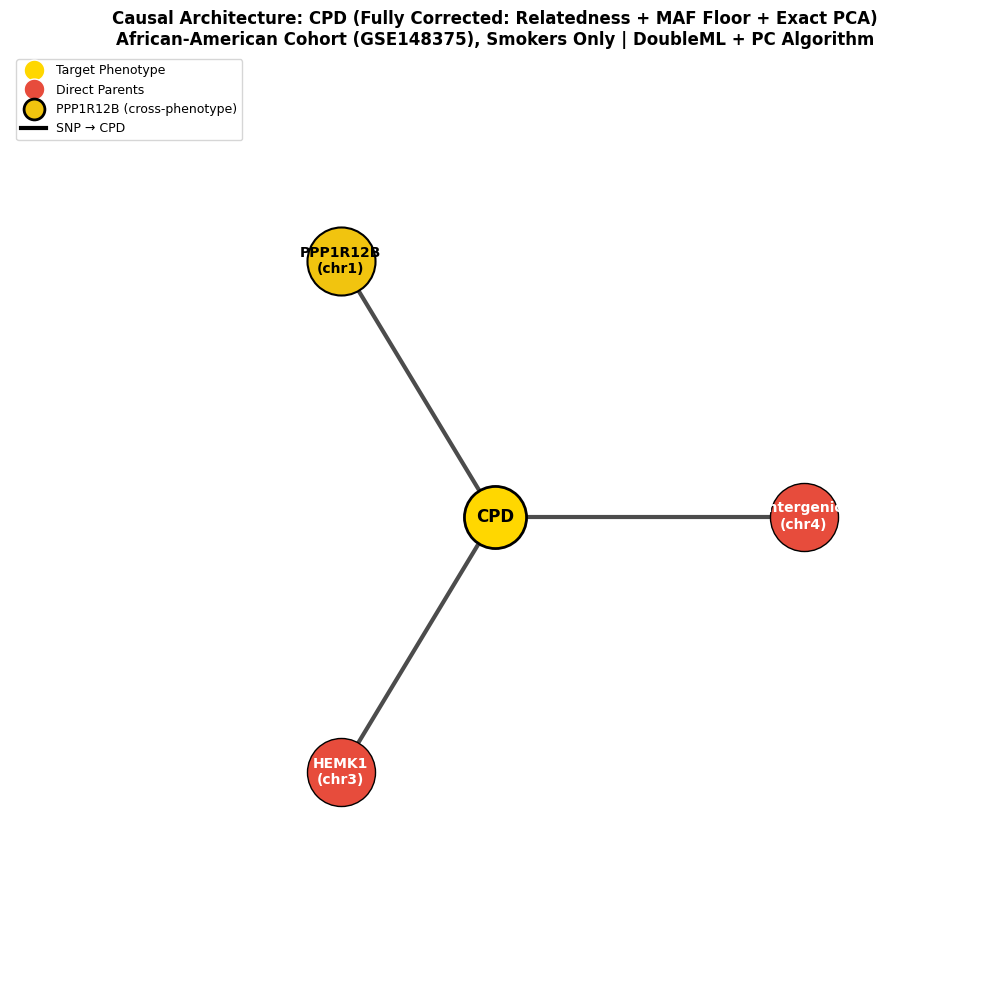

Saved.


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import os

out_dir = r"C:\Users\user\Downloads\GSE148375_clean"

def make_label(snp_id, gene_map, row):
    gene = gene_map.get(snp_id, "?")
    if gene.startswith("intergenic_chr"):
        gene = "intergenic"
    return f"{gene}\n(chr{row['Chr']})"

fig, ax = plt.subplots(figsize=(10, 10))
center = np.array([0, 0])
ax.scatter(*center, s=2000, c="gold", zorder=5, edgecolors="black", linewidths=2)
ax.text(*center, "CPD", ha="center", va="center", fontsize=12, fontweight="bold", zorder=6)

snp_order = final_shortlist_cpd["probe_id"].tolist()
inner_r = 3.5
pos = {"CPD": center}
for i, snp in enumerate(snp_order):
    angle = 2 * np.pi * i / len(snp_order)
    pos[snp] = inner_r * np.array([np.cos(angle), np.sin(angle)])

for u, v in edges_directed_cpd:
    if u in pos and v in pos:
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color="black", linewidth=3, zorder=1, alpha=0.7)

for snp in snp_order:
    row = final_shortlist_cpd[final_shortlist_cpd["probe_id"] == snp].iloc[0]
    color = "#f1c40f" if "2277017" in snp else "#e74c3c"
    ax.scatter(*pos[snp], s=2400, c=color, zorder=4, edgecolors="black", linewidths=1.5 if "2277017" in snp else 1)
    label = make_label(snp, gene_map_cpd_final, row)
    text_color = "black" if "2277017" in snp else "white"
    ax.text(*pos[snp], label, ha="center", va="center", fontsize=10, fontweight="bold", color=text_color, zorder=6)

ax.set_xlim(-5.5, 5.5)
ax.set_ylim(-5.5, 5.5)
ax.axis("off")
ax.set_title("Causal Architecture: CPD (Fully Corrected: Relatedness + MAF Floor + Exact PCA)\nAfrican-American Cohort (GSE148375), Smokers Only | DoubleML + PC Algorithm",
              fontsize=12, fontweight="bold")

legend_elements = [
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='gold', markersize=15, label='Target Phenotype'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=15, label='Direct Parents'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#f1c40f', markersize=15, markeredgewidth=2, markeredgecolor='black', label='PPP1R12B (cross-phenotype)'),
    plt.Line2D([0],[0], color='black', linewidth=3, label='SNP → CPD'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, "sunflower_cpd_AA_final_corrected.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

In [1]:
import numpy as np
import json
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
import os

out_dir = r"C:\Users\user\Downloads\GSE148375_clean"
X_pc_full_cpd = np.load(os.path.join(out_dir, "pc_input_cpd_final.npy"))
with open(os.path.join(out_dir, "pc_col_names_cpd_final.json")) as f:
    col_names_cpd = json.load(f)

n_nodes = len(col_names_cpd)
outcome_idx = col_names_cpd.index("CPD")

def run_pc_get_parents(X, col_names, outcome_name, alpha_val):
    n_nodes = len(col_names)
    outcome_idx = col_names.index(outcome_name)
    bk = BackgroundKnowledge()
    nodes = [GraphNode(name) for name in col_names]
    for i in range(n_nodes - 1):
        bk.add_node_to_tier(nodes[i], 0)
    bk.add_node_to_tier(nodes[outcome_idx], 1)

    cg = pc(data=X, alpha=alpha_val, indep_test=fisherz, stable=True,
            uc_rule=0, uc_priority=2, background_knowledge=bk,
            verbose=False, show_progress=False, node_names=col_names)

    adj = cg.G.graph
    edges_directed, edges_undirected = [], []
    for i in range(n_nodes):
        for j in range(i+1, n_nodes):
            if adj[i,j] == -1 and adj[j,i] == 1:
                edges_directed.append((col_names[i], col_names[j]))
            elif adj[i,j] == 1 and adj[j,i] == -1:
                edges_directed.append((col_names[j], col_names[i]))
            elif adj[i,j] == -1 and adj[j,i] == -1:
                edges_undirected.append((col_names[i], col_names[j]))

    direct_parents = set()
    for u, v in edges_directed:
        if v == outcome_name:
            direct_parents.add(u)
    for u, v in edges_undirected:
        if outcome_name in (u, v):
            direct_parents.add(v if u == outcome_name else u)
    return direct_parents

for alpha_val in [0.0001, 0.001, 0.005]:
    parents = run_pc_get_parents(X_pc_full_cpd, col_names_cpd, "CPD", alpha_val)
    print(f"alpha={alpha_val}: {len(parents)} direct parents: {sorted(parents)}")

alpha=0.0001: 3 direct parents: ['exm2265806-0_B_R_1984855512', 'exm2277017-0_T_R_1989215336', 'exm318398-0_B_F_1922126681']
alpha=0.001: 3 direct parents: ['exm2265806-0_B_R_1984855512', 'exm2277017-0_T_R_1989215336', 'exm318398-0_B_F_1922126681']
alpha=0.005: 3 direct parents: ['exm2265806-0_B_R_1984855512', 'exm2277017-0_T_R_1989215336', 'exm318398-0_B_F_1922126681']


c:\Users\user\Desktop\ai causal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
